# Iterative Information Bottleneck on CIFAR-10 Patches
This notebook applies the **iterative information bottleneck** algorithm from [Tishby *et al.*, arXiv:physics/0004057](https://doi.org/10.48550/arXiv.physics/0004057) to noisy CIFAR-10 patches. The noisy variable is defined as \(X = \sqrt{a_t}\phi + \sqrt{1 - a_t}\eta\), where \(\phi\) is the clean 10×10 patch, \(\eta\) is white noise, and \(a_t\in[0,1]\) controls the noise level. The goal is to compress \(X\) into a discrete bottleneck \(T\) that preserves information about the **center RGB pixel** \(Y\) via the Blahut–Arimoto-like updates described in the paper.


In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## Noisy patch dataset
We crop CIFAR-10 images to **10×10 patches** and treat the **center pixel** \(Y\) as the relevant variable. The noisy/uncompressed variable is constructed using \(X = \sqrt{a_t}\phi + \sqrt{1 - a_t}\eta\), so the encoder must rely on the patch context to reconstruct the center pixel when noise is added.


In [2]:
PATCH_SIZE = 10
NUM_SAMPLES = 4000
LEVELS = 4
BATCH_SIZE = 128

transform = transforms.ToTensor()
cifar = torchvision.datasets.CIFAR10(
    root="data", train=True, transform=transform, download=True
)


class PatchCenterDataset(Dataset):
    def __init__(self, base_dataset, patch_size=PATCH_SIZE):
        self.base_dataset = base_dataset
        self.patch_size = patch_size
        self.center = patch_size // 2

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]
        _, height, width = image.shape
        max_top = height - self.patch_size
        max_left = width - self.patch_size
        top = torch.randint(0, max_top + 1, (1,)).item()
        left = torch.randint(0, max_left + 1, (1,)).item()
        patch = image[:, top : top + self.patch_size, left : left + self.patch_size]
        center = patch[:, self.center, self.center]
        return patch, center


def quantize_center(center, levels=LEVELS):
    clipped = center.clamp(0.0, 1.0)
    quantized = (clipped * (levels - 1)).round().clamp(0, levels - 1).long()
    r = quantized[0].item()
    g = quantized[1].item()
    b = quantized[2].item()
    return r * (levels ** 2) + g * levels + b


dataset = PatchCenterDataset(cifar)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

noisy_vectors = []
center_colors = []
quantized_labels = []
raw_patches = []
alpha_values = []

collected = 0
for batch_patches, batch_centers in loader:
    for patch, center in zip(batch_patches, batch_centers):
        if collected >= NUM_SAMPLES:
            break
        alpha = torch.rand(1).item()
        noise = torch.randn_like(patch)
        noisy_patch = math.sqrt(alpha) * patch + math.sqrt(1 - alpha) * noise
        noisy_vectors.append(noisy_patch.flatten().numpy())
        center_colors.append(center.numpy())
        quantized_labels.append(quantize_center(center))
        raw_patches.append(patch.numpy())
        alpha_values.append(alpha)
        collected += 1
    if collected >= NUM_SAMPLES:
        break

noisy_matrix = np.stack(noisy_vectors)
center_colors = np.stack(center_colors)
quantized_labels = np.array(quantized_labels, dtype=int)
raw_patches = np.stack(raw_patches)
alpha_values = np.array(alpha_values)

print(f"Collected {noisy_matrix.shape[0]} noisy patches.")


Files already downloaded and verified
Collected 4000 noisy patches.


## Iterative Information Bottleneck updates
We treat \(X\) as the noisy patch vector and \(Y\) as the quantized center color. The algorithm iteratively updates \(P(T|X)\), \(P(T)\), and \(P(Y|T)\) to minimize \(I(X;T) - \beta I(T;Y)\) using the updates derived from the Blahut–Arimoto style iterations in the original paper.


In [3]:
EPS = 1e-12


def logsumexp(a, axis=-1):
    a_max = np.max(a, axis=axis, keepdims=True)
    return a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))


def run_iterative_ib(
    labels,
    beta=2.0,
    K_T=8,
    max_iter=100,
    tol=1e-6,
):
    N = labels.shape[0]
    K_Y = (LEVELS ** 3)
    p_t = np.ones(K_T) / K_T
    p_y_given_t = np.ones((K_T, K_Y)) / K_Y
    one_hot_y = np.eye(K_Y)[labels]

    history = []
    prev_objective = None

    for iteration in range(1, max_iter + 1):
        log_p_t = np.log(p_t + EPS)
        log_p_y_given_t = np.log(p_y_given_t + EPS)
        log_scores = log_p_t[None, :] + beta * log_p_y_given_t[:, labels].T
        log_p_t_given_x = log_scores - logsumexp(log_scores, axis=1)
        p_t_given_x = np.exp(log_p_t_given_x)

        p_t = p_t_given_x.mean(axis=0)
        numerator = p_t_given_x.T @ one_hot_y
        p_y_given_t = numerator / (p_t[:, None] + EPS)

        I_xt = np.sum(
            p_t_given_x
            * (np.log(p_t_given_x + EPS) - np.log(p_t[None, :] + EPS))
        ) / N
        p_y = np.bincount(labels, minlength=K_Y) / N
        I_ty = np.sum(
            p_t[:, None]
            * (p_y_given_t * (np.log(p_y_given_t + EPS) - np.log(p_y[None, :] + EPS)))
        )
        objective = I_xt - beta * I_ty

        history.append(
            {
                "iteration": iteration,
                "objective": objective,
                "I_x_t": I_xt,
                "I_t_y": I_ty,
            }
        )

        if prev_objective is not None and abs(objective - prev_objective) < tol:
            break
        prev_objective = objective

    return {
        "p_t": p_t,
        "p_t_given_x": p_t_given_x,
        "p_y_given_t": p_y_given_t,
        "history": history,
        "labels": labels,
    }


BETA = 2.0
K_T = 8
results = run_iterative_ib(quantized_labels, beta=BETA, K_T=K_T)


## Visualizations and cluster interpretations
We plot the IB objective and mutual informations as the iterations progress. Each cluster \(T\) yields a prototype center color, and we display representative patches that most strongly activate individual clusters to show how adjacent context compensates for the injected noise.


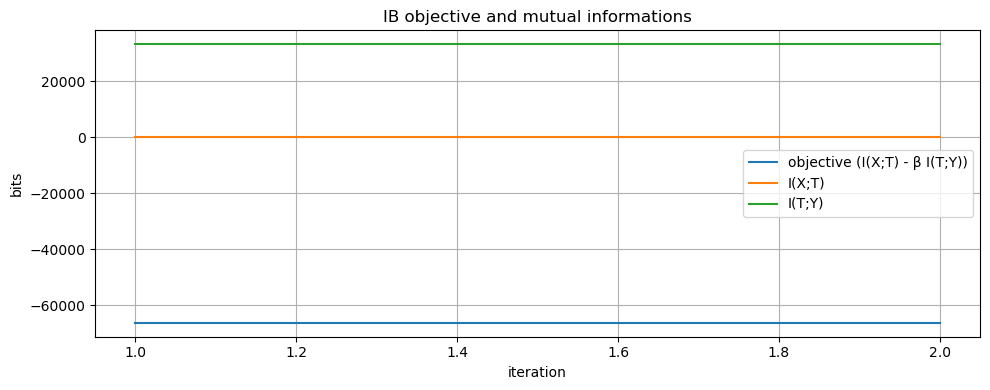

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1701.7804315429014..1929.0274975997677].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1701.7804315429014..1929.0274975997677].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1701.7804315429014..1929.0274975997677].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1701.7804315429014..1929.0274975997677].
C:\Users\henhen724\AppData\Local\Temp\ipykernel_372000\1355171225.py:61: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\henhen724\miniconda3\envs\diffusion_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

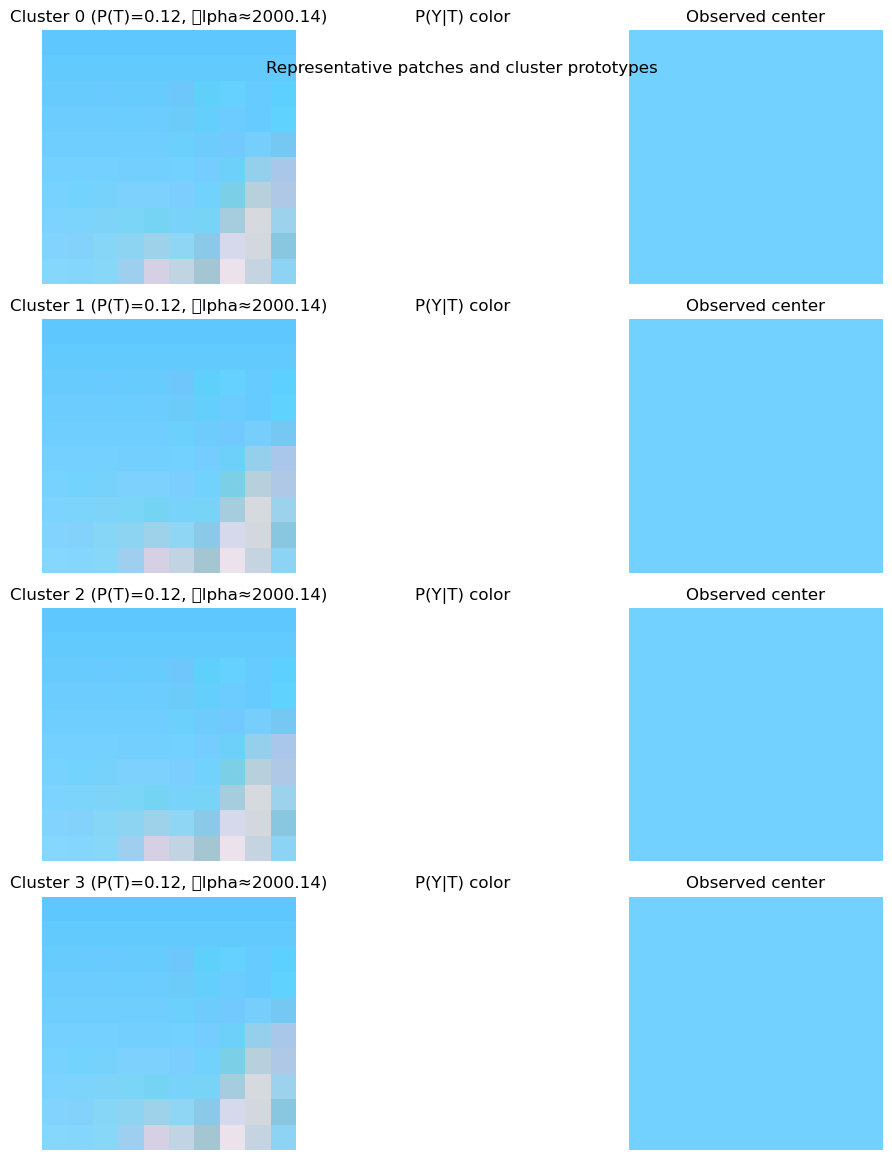

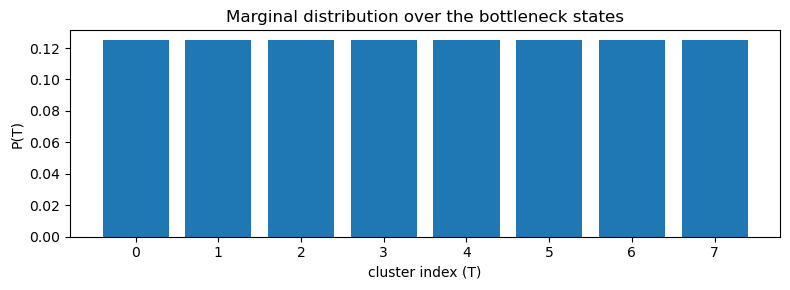

In [4]:
history = results["history"]
iterations = [h["iteration"] for h in history]
objective_vals = [h["objective"] for h in history]
I_xt_vals = [h["I_x_t"] for h in history]
I_ty_vals = [h["I_t_y"] for h in history]

plt.figure(figsize=(10, 4))
plt.plot(iterations, objective_vals, label="objective (I(X;T) - β I(T;Y))")
plt.plot(iterations, I_xt_vals, label="I(X;T)")
plt.plot(iterations, I_ty_vals, label="I(T;Y)")
plt.xlabel("iteration")
plt.ylabel("bits")
plt.title("IB objective and mutual informations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

p_t = results["p_t"]
p_t_given_x = results["p_t_given_x"]
cluster_probs = results["p_t"]
cluster_colors = (
    (p_t_given_x.T @ center_colors) / (cluster_probs[:, None] + EPS)
)
cluster_noise = (
    (p_t_given_x.T @ alpha_values) / (cluster_probs + EPS)[:, None]
).flatten()

repr_indices = np.argmax(p_t_given_x, axis=0)
num_display = min(K_T, 4)
sorted_clusters = np.argsort(-cluster_probs)[:num_display]

fig, axes = plt.subplots(num_display, 3, figsize=(9, num_display * 3))
if num_display == 1:
    axes = axes.reshape((1, 3))

for row, cluster_idx in enumerate(sorted_clusters):
    idx = repr_indices[cluster_idx]
    patch = raw_patches[idx]
    patch_img = np.clip(patch.transpose(1, 2, 0), 0, 1)
    predicted_rgb = cluster_colors[cluster_idx]
    true_rgb = center_colors[idx]
    noise_level = cluster_noise[cluster_idx]
    title = f"Cluster {cluster_idx} (P(T)={cluster_probs[cluster_idx]:.2f}, \alpha≈{noise_level:.2f})"

    axes[row, 0].imshow(patch_img)
    axes[row, 0].set_title(title)
    axes[row, 0].axis("off")

    swatch_pred = np.ones((40, 40, 3)) * predicted_rgb
    axes[row, 1].imshow(swatch_pred)
    axes[row, 1].set_title("P(Y|T) color")
    axes[row, 1].axis("off")

    swatch_true = np.ones((40, 40, 3)) * true_rgb
    axes[row, 2].imshow(swatch_true)
    axes[row, 2].set_title("Observed center")
    axes[row, 2].axis("off")

plt.suptitle("Representative patches and cluster prototypes", y=0.92)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.bar(np.arange(K_T), p_t)
plt.xlabel("cluster index (T)")
plt.ylabel("P(T)")
plt.title("Marginal distribution over the bottleneck states")
plt.tight_layout()
plt.show()


## Takeaways
Injecting noise in the form \(X = \sqrt{a_t}\phi + \sqrt{1 - a_t}\eta\) forces the bottleneck to pool information from adjacent pixels because the center alone is no longer reliable. The iterative updates gradually reshape \(P(T|X)\) and \(P(Y|T)\) so that each discrete state preserves the most relevant color statistics for a given cluster of noisy inputs.
